In [1]:
#imports

!pip install numpy pandas matplotlib scikit-learn ucimlrepo seaborn
!pip install ucimlrepo
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from ucimlrepo import fetch_ucirepo
from sklearn import preprocessing
from sklearn.preprocessing import OneHotEncoder
import seaborn as sns




[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [ ]:
df = pd.read_csv(   "https://raw.githubusercontent.com/guipsamora/pandas_exercises/master/04_Apply/Students_Alcohol_Consumption/student-mat.csv", sep=None, engine="python")

print(df.shape)
print(df.head())

(395, 33)
  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        6   5   6   6  
1      5        3      3     1     1      3        4   5   5   6  
2      4        3      2     2     3      3       10   7   8  10  
3      3        2      2     1     1      5        2  15  14  15  
4      4        3      2     1     2      5        4   6  10  10  

[5 rows x 33 columns]


In [16]:
#loading the dataset
student_performance = df
X = student_performance.drop(["G3", "G2", "G1"], axis=1)
y = student_performance[["G3", "G2", "G1"]]


In [17]:
#inspecting the dataset
print(f"Features number of rows :{X.shape[0]}") #number of rows in the features dataset
print(f"Targets number of rows :{y.shape[0]}") #number of rows in the targets dataset
print(f"Features number of columns :{X.shape[1]}") #number of columns in the features dataset
print(f"Targets number of columns :{y.shape[1]}") #number of columns in the targets dataset

Features number of rows :395
Targets number of rows :395
Features number of columns :30
Targets number of columns :3


- Number of rows match up, shows indexing is done well

In [18]:
#inspecting variable types
X.info()
y.info()
#most of the features are categorical and the target is numerical, whilst some of the features are numerical

<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 30 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    str  
 1   sex         395 non-null    str  
 2   age         395 non-null    int64
 3   address     395 non-null    str  
 4   famsize     395 non-null    str  
 5   Pstatus     395 non-null    str  
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   Mjob        395 non-null    str  
 9   Fjob        395 non-null    str  
 10  reason      395 non-null    str  
 11  guardian    395 non-null    str  
 12  traveltime  395 non-null    int64
 13  studytime   395 non-null    int64
 14  failures    395 non-null    int64
 15  schoolsup   395 non-null    str  
 16  famsup      395 non-null    str  
 17  paid        395 non-null    str  
 18  activities  395 non-null    str  
 19  nursery     395 non-null    str  
 20  higher      395 non-null    str  
 21  inte

In [19]:
#identifying the target variable
#G3 is the final grade, it also is highly correlated with the other two grades G1 and G2, so we will be using it as our target variable
#i will store it under the name y_G3
y_G3 = y["G3"]
#the features remain the same, so i will keep them under the name X


In [20]:
# feature engineering and data cleaning
#checking for null values in the features dataset and the target variable
print(X.isnull().sum())
print(y_G3.isnull().sum())
#there are no null values in the features dataset, so we can proceed to the next step

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
dtype: int64
0


In [21]:
#we will split the dataset into
#Categorical and nominal
# Then we will split the categorical features into ordinal and nominal, ordinal we will encode using label encoding and nominal we will encode using one hot encoding
categorical_features_nominal = X.select_dtypes(include=["str"]).columns
categorical_features_ordinal = X.select_dtypes(include=["int64", "float64"]).columns
print(f"Categorical features nominal: {categorical_features_nominal}")
print(f"Categorical features ordinal: {categorical_features_ordinal}")
#this matches up with what variables we need to split into categorical and numerical from the brief
# essentially categorical features have nominal data, so there is no order of significance. Ordinal data there is an order of significance ex: more absences are worse



Categorical features nominal: Index(['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob',
       'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities',
       'nursery', 'higher', 'internet', 'romantic'],
      dtype='str')
Categorical features ordinal: Index(['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel',
       'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences'],
      dtype='str')


In [22]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y_G3, test_size=0.2, random_state=42)

In [23]:
#creating a copy of the features dataset just incase
X_copy = X.copy()


In [24]:

#one hot encoding the categorical features
one_hot = OneHotEncoder(sparse_output=False, handle_unknown='ignore') 
one_hot_encoded_train = one_hot.fit_transform(X_train[categorical_features_nominal]) #only transforming the training set, we will use the same encoder to transform the test set later on
X_train_nominal = pd.DataFrame(one_hot_encoded_train, columns=one_hot.get_feature_names_out(categorical_features_nominal), index=X_train.index) #creating a new dataframe for the one hot encoded features, and keeping the same index as the original dataframe

one_hot_encoded_test = one_hot.transform(X_test[categorical_features_nominal])
X_test_nominal = pd.DataFrame(one_hot_encoded_test, columns=one_hot.get_feature_names_out(categorical_features_nominal), index=X_test.index) #creating a new dataframe for the one hot encoded features, and keeping the same index as the original dataframe
    
#add the new df in places of the old ones for both training and test sets
X_train_encoded = pd.concat(
    [X_train.drop(columns=categorical_features_nominal), X_train_nominal],
    axis=1
)

X_test_encoded = pd.concat(
    [X_test.drop(columns=categorical_features_nominal), X_test_nominal],
    axis=1
)

In [25]:
#scaling numerical inputs for knn
StandardScaler = preprocessing.StandardScaler()

X_train_knn_scaled = StandardScaler.fit_transform(X_train_encoded)
X_test_knn_scaled = StandardScaler.transform(X_test_encoded)

X_train_knn_scaled = pd.concat(
    [pd.DataFrame(X_train_knn_scaled, columns=X_train_encoded.columns, index=X_train.index)],
    axis=1
)

X_test_knn_scaled = pd.concat(
    [pd.DataFrame(X_test_knn_scaled, columns=X_test_encoded.columns, index=X_test.index)],
    axis=1
)

****EDA****
1. We will conduct summary statistics for the feature engineered dataset
2. A histogram of the final grade
3. Find some meaningfull relationships between some variables

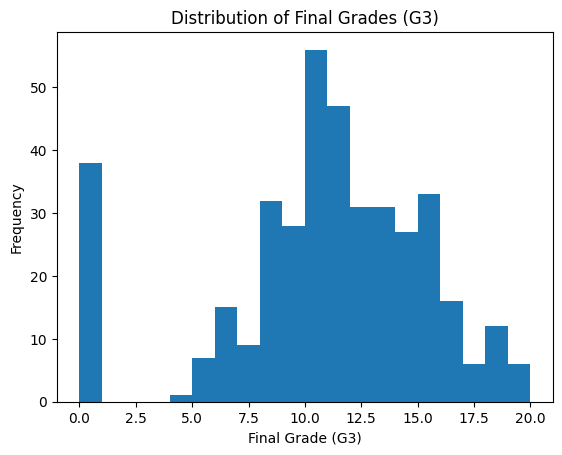

In [26]:
# histogram of final grade
plt.hist(y_G3, bins=20)
plt.title("Distribution of Final Grades (G3)")
plt.xlabel("Final Grade (G3)")
plt.ylabel("Frequency")
plt.show()


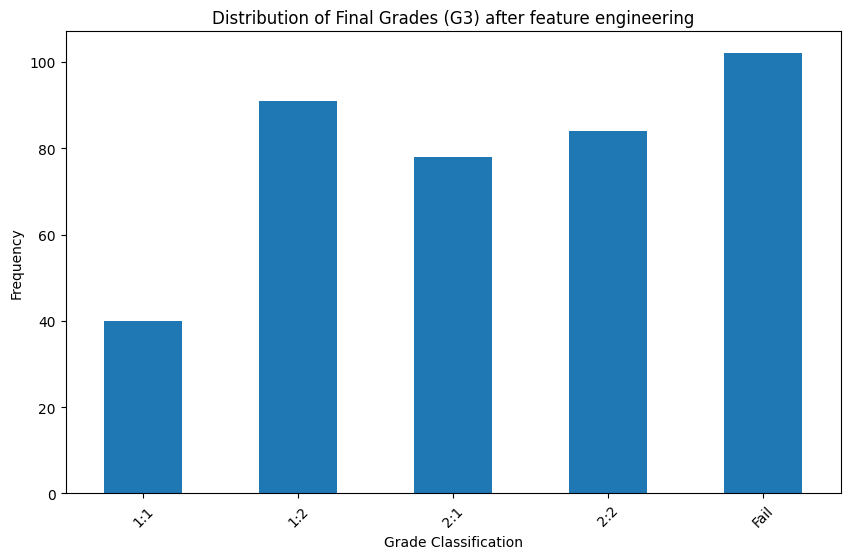

In [27]:
# we will feature engineer the final grades to see where students lie the most
# Create a new Series for classification
y_G3_classified = pd.Series(index=y_G3.index, dtype='object')

y_G3_classified.loc[y_G3 >= 16] = '1:1'
y_G3_classified.loc[y_G3.between(13, 15)] = '1:2'
y_G3_classified.loc[y_G3.between(11, 12)] = '2:1'
y_G3_classified.loc[y_G3.between(9, 10)] = '2:2'
y_G3_classified.loc[y_G3 < 9] = 'Fail'

# plotting the distribution of the final grades after feature engineering
plt.figure(figsize=(10, 6))
y_G3_classified.value_counts().sort_index().plot(kind='bar')
plt.title("Distribution of Final Grades (G3) after feature engineering")
plt.xlabel("Grade Classification")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()


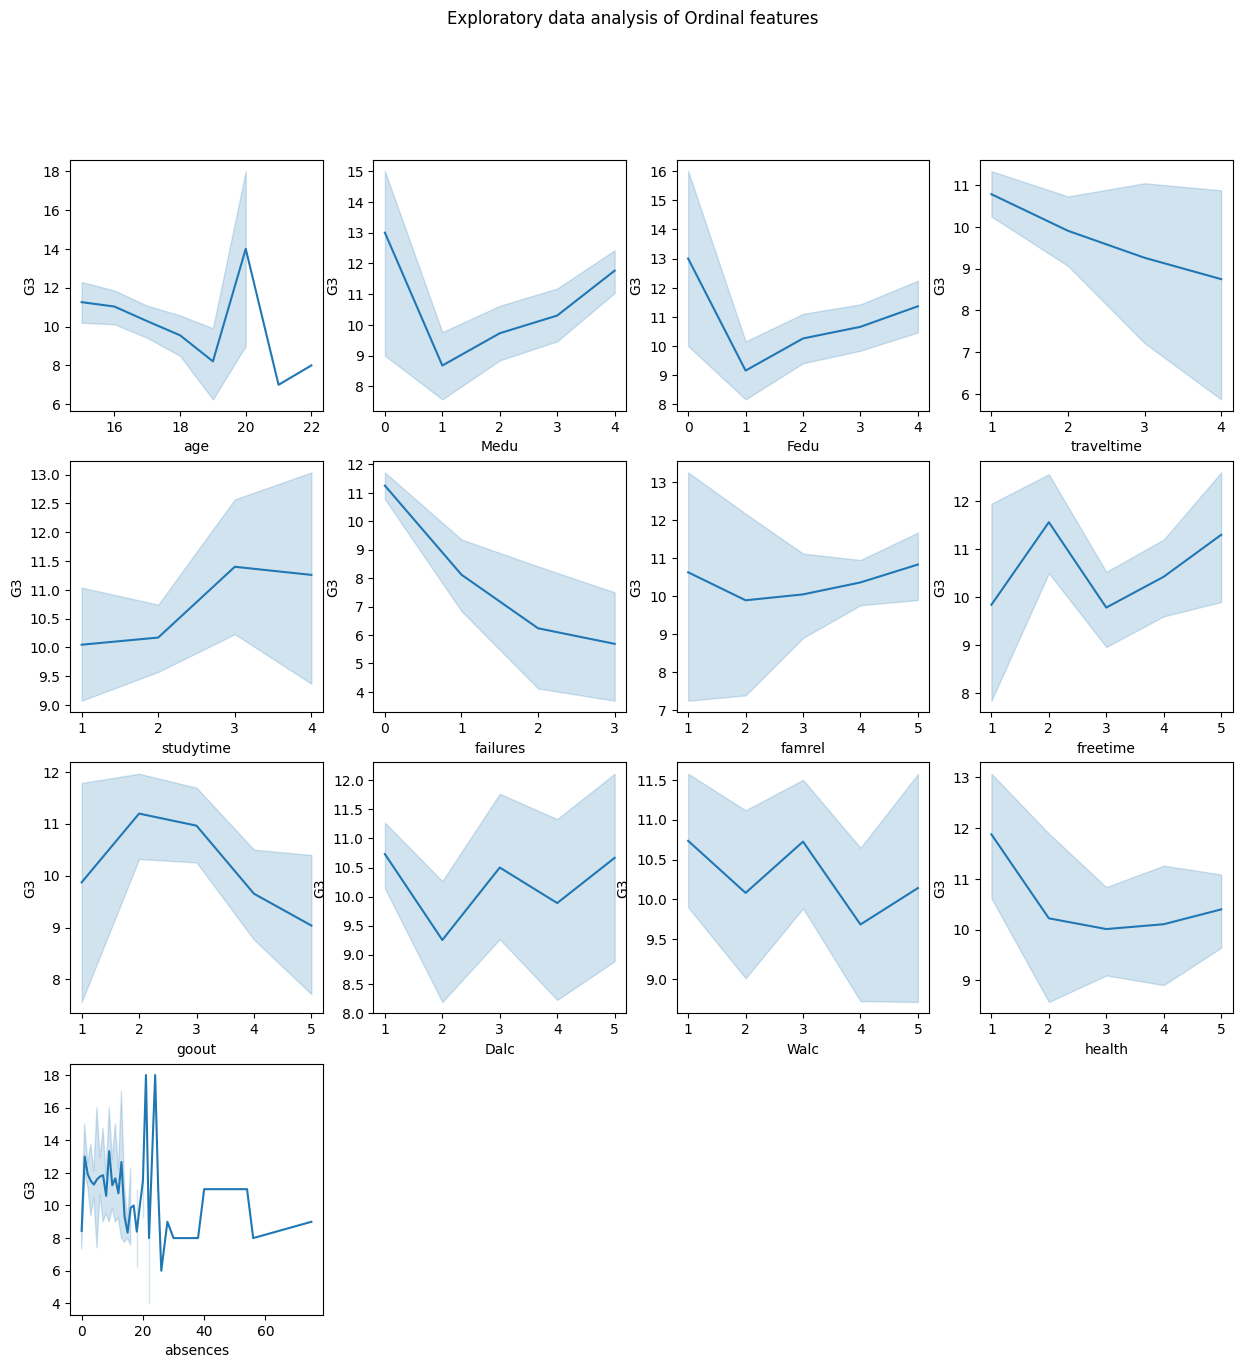

In [28]:

fig, axes = plt.subplots(4, 4, figsize=(15, 15))
fig.suptitle("Exploratory data analysis of Ordinal features")
for i, feature in enumerate(categorical_features_ordinal):
    sns.lineplot(ax = axes[i//4, i%4], x=X[feature], y = y_G3)
plots_to_delete = [(3, 3), (3, 2), (3, 1)] #empty plots to delete since we have 13 features and not 16
for row, col in plots_to_delete:
    fig.delaxes(axes[row, col]) # removing the last subplot since we have 13 features and not 16


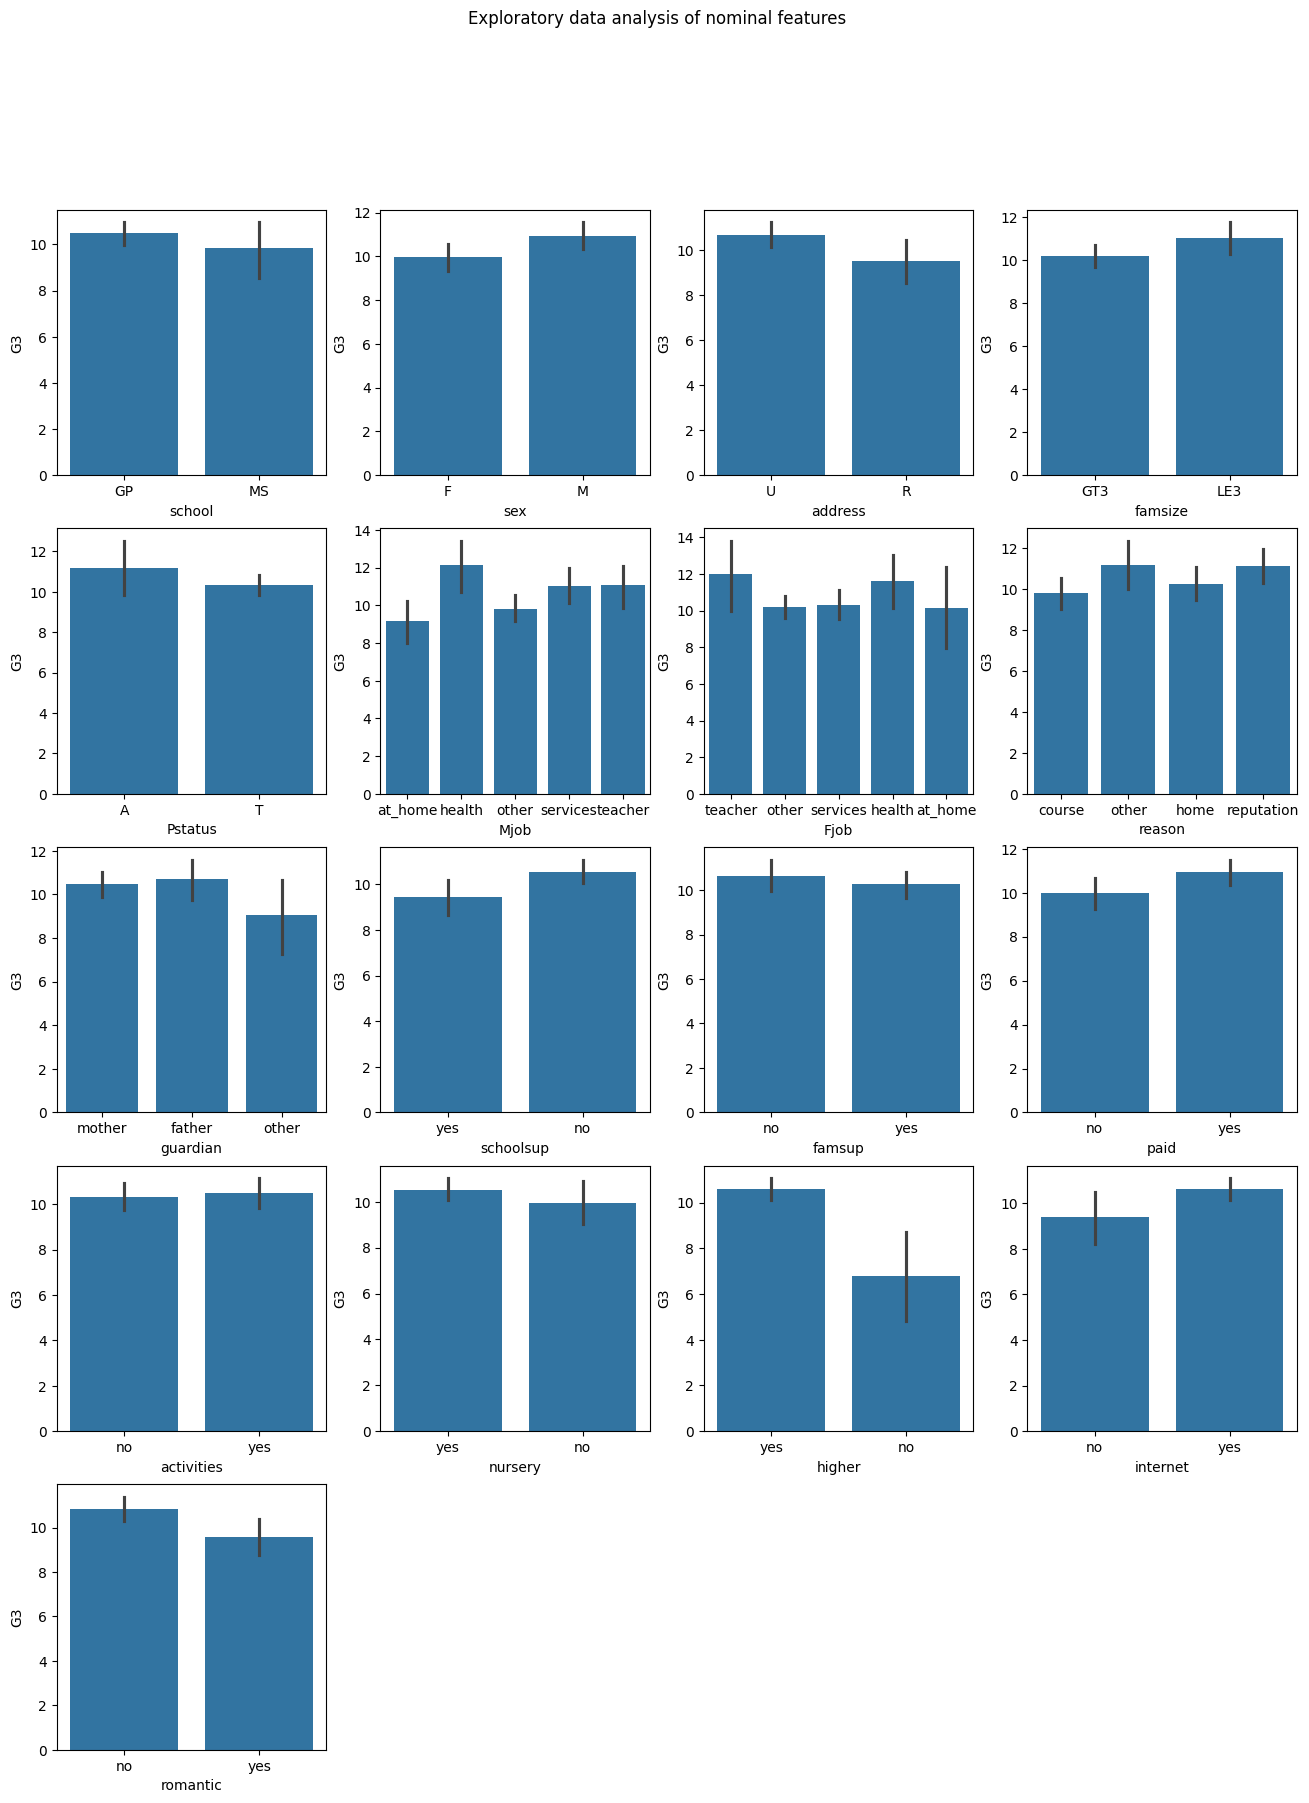

In [29]:

fig, axes = plt.subplots(5, 4, figsize=(16, 20))
fig.suptitle("Exploratory data analysis of nominal features")
for i, feature in enumerate(categorical_features_nominal):
    sns.barplot(ax = axes[i//4, i%4], x=X[feature], y = y_G3)
plots_to_delete = [(4, 3), (4, 2), (4, 1)] #empty plots to delete since we have 13 features and not 16
for row, col in plots_to_delete:
    fig.delaxes(axes[row, col]) # removing the last subplot since we have 13 features and not 16


In [30]:
#Linear regression
lr = sklearn.linear_model.LinearRegression()
lr.fit(X_train_encoded, y_train)
y_pred_lr = lr.predict(X_test_encoded)

#metrics for linear regression
from sklearn.metrics import mean_absolute_error, r2_score
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)
print(f"Linear Regression MAE: {mae_lr}")
print(f"Linear Regression R2 Score: {r2_lr}")

Linear Regression MAE: 3.3952609258019226
Linear Regression R2 Score: 0.1414924741119573


In [31]:
#knn regression
from sklearn.neighbors import KNeighborsRegressor
knn = KNeighborsRegressor(n_neighbors=5)
model_knn = knn.fit(X_train_knn_scaled, y_train)
y_pred_knn = model_knn.predict(X_test_knn_scaled)

#metrics for knn regression
mae_knn = mean_absolute_error(y_test, y_pred_knn)
r2_knn = r2_score(y_test, y_pred_knn)
print(f"KNN Regression MAE: {mae_knn}")
print(f"KNN Regression R2 Score: {r2_knn}")


KNN Regression MAE: 3.754430379746835
KNN Regression R2 Score: -0.04117619479261081


In [32]:
#Decision tree regression
from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor(random_state=42)
model_dt = dt.fit(X_train_encoded, y_train)
y_pred_dt = model_dt.predict(X_test_encoded)

#metrics for decision tree regression
mae_dt = mean_absolute_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)
print(f"Decision Tree Regression MAE: {mae_dt}")
print(f"Decision Tree Regression R2 Score: {r2_dt}")


Decision Tree Regression MAE: 3.569620253164557
Decision Tree Regression R2 Score: -0.11241521582846237
